Análisis de datos de ventas

Beatriz Abigail Trujillo Martínez

Ventas y clientes

In [15]:
import pandas as pd

# Cargar los datos
ventas = pd.read_csv('sales_data_2023.csv')
clientes= pd.read_csv('customer_data_2023.csv')

# Para visualizar las primeras 5 filas 
print ("Ventas",ventas.head())
print ("Clientes", clientes.head())

Ventas    Sale_ID  Customer_ID  Sale_Amount   Sale_Date Geography
0        1           38        31.11  2023-05-03      West
1        2           18       191.54  2023-03-06     South
2        3          197       283.74  2023-06-23      East
3        4          185       367.13  2023-02-09     South
4        5          171       188.52  2023-12-25     South
Clientes    Customer_ID Customer_Name  Customer_Age Geography
0            1    Customer_1            20      West
1            2    Customer_2            69     North
2            3    Customer_3            57      West
3            4    Customer_4            66      East
4            5    Customer_5            59     South


In [16]:
#Numero de registros y columnas"
#Ventas
print ("ventas",ventas.shape)

#Clientes
print ("clientes",clientes.shape)

ventas (1000, 5)
clientes (300, 4)


In [17]:
# Revisar columnas y tipos de datos
#Nombre de columnas
print("Columnas de ventas:",ventas.columns.tolist())
print ("Columnas de clientes:",clientes.columns.tolist())


#Tipo de datos
print ("\nTipos de datos = ventas:")
print (ventas.dtypes)

print ("\nTipos de datos = clientes:")
print (clientes.dtypes)

Columnas de ventas: ['Sale_ID', 'Customer_ID', 'Sale_Amount', 'Sale_Date', 'Geography']
Columnas de clientes: ['Customer_ID', 'Customer_Name', 'Customer_Age', 'Geography']

Tipos de datos = ventas:
Sale_ID          int64
Customer_ID      int64
Sale_Amount    float64
Sale_Date       object
Geography       object
dtype: object

Tipos de datos = clientes:
Customer_ID       int64
Customer_Name    object
Customer_Age      int64
Geography        object
dtype: object


In [18]:
# Tipo de datos de la base de datos junto con nulos
print(ventas.info())
print(clientes.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sale_ID      1000 non-null   int64  
 1   Customer_ID  1000 non-null   int64  
 2   Sale_Amount  1000 non-null   float64
 3   Sale_Date    1000 non-null   object 
 4   Geography    1000 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 39.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Customer_ID    300 non-null    int64 
 1   Customer_Name  300 non-null    object
 2   Customer_Age   300 non-null    int64 
 3   Geography      300 non-null    object
dtypes: int64(2), object(2)
memory usage: 9.5+ KB
None


La base de datos no contiene nulos, esto se puede visualizar en la tabla anterior donde se encuentra la columna Non-Null Count, el cual nos menciona que no contiene nulos en los 1000 registros que esta conformada la base de datos.
Por otro lado, el tipo de dato de sale_date es incorrecto dado que son fechas se debe de manejar datetime64.

In [21]:
# Tipo de datos 
print(ventas.dtypes)
print(clientes.dtypes)

Sale_ID          int64
Customer_ID      int64
Sale_Amount    float64
Sale_Date       object
Geography       object
dtype: object
Customer_ID       int64
Customer_Name    object
Customer_Age      int64
Geography        object
dtype: object


In [26]:
# Datos nulos
print("Datos nulos en ventas:",ventas.isnull().sum())
print("Datos nulos en clientes:",clientes.isnull().sum())
print("Datos nulos en el data frame de ventas:",ventas.isna().sum().sum())
print("Datos nulos en el data frame de clientes:",clientes.isna().sum().sum())

Datos nulos en ventas: Sale_ID        0
Customer_ID    0
Sale_Amount    0
Sale_Date      0
Geography      0
dtype: int64
Datos nulos en clientes: Customer_ID      0
Customer_Name    0
Customer_Age     0
Geography        0
dtype: int64
Datos nulos en el data frame de ventas: 0
Datos nulos en el data frame de clientes: 0


In [27]:
# Cambio de tipo de dato
# Dato que el campo de sale_date se encuentra incorrecto el tipo de dato se decide cambiar de formato
#Fecha
ventas["Sale_Date"]=pd.to_datetime(ventas["Sale_Date"],format="mixed",dayfirst=False,errors="coerce")

print(ventas["Sale_Date"].dtype)
print(ventas["Sale_Date"].isnull().sum())
print(ventas["Sale_Date"].min(), "_",
      ventas["Sale_Date"].max())

datetime64[ns]
0
2023-01-01 00:00:00 _ 2023-12-31 00:00:00


In [31]:
#Geographic conocer que categorias contiene
# Devuelve un conteo de cada valor único
conteo = ventas["Geography"].value_counts()
print(f"La columna tiene {conteo} categorías únicas.")

La columna tiene Geography
North    262
West     259
South    240
East     239
Name: count, dtype: int64 categorías únicas.


In [35]:
#Cambiar el tipo ed dato de Geography
ventas["Geography"] = ventas["Geography"].astype("category")

#Tipo de dato y categorias
print(f"Tipo de dato: {ventas['Geography'].dtype}")
print(f"Categorías disponibles: {ventas['Geography'].cat.categories.tolist()}")

Tipo de dato: category
Categorías disponibles: ['East', 'North', 'South', 'West']


In [36]:
# Filas que contienen algo que NO es un número (dígito o punto)
# El patrón r'[^\d\.]' busca cualquier carácter que no sea 0-9 ni punto
sospechosos = ventas[ventas['Sale_Amount'].astype(str).str.contains(r'[^\d\.]', na=False)]

# Mostrar los valores únicos de esas filas para ver qué caracteres son
print(sospechosos['Sale_Amount'].unique())

[]


In [38]:
#Transformar el campo de sale_amount
ventas["Sale_Amount"]=(ventas["Sale_Amount"].astype(str).str.replace("$","",regex=False))
ventas["Sale_Amount"]=pd.to_numeric(ventas["Sale_Amount"],errors="coerce")
print(ventas["Sale_Amount"].dtype)
print(ventas["Sale_Amount"].describe())

float64
count    1000.000000
mean      253.532920
std       142.291244
min        10.510000
25%       124.297500
50%       258.190000
75%       373.130000
max       500.740000
Name: Sale_Amount, dtype: float64


In [17]:
#Revisar si los campos se convirtieron en el tipo de campo deseado
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Sale_ID      1000 non-null   int64         
 1   Customer_ID  1000 non-null   int64         
 2   Sale_Amount  1000 non-null   float64       
 3   Sale_Date    1000 non-null   datetime64[ns]
 4   Geography    1000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 39.2+ KB


En la tabla anterior se puede observar que en la columna dtype que es el tipo de dato, las variables de sale_date y geography estan ahora ya correctas con el tipo de campo correspondiente

In [18]:
# Cuenta cuántas filas están repetidas completamente
datos.duplicated().sum()

np.int64(0)

Resultados

Ventas por región

In [22]:
#Ventas agrupadas por región
import pandas as pd
import matplotlib.pyplot as plt

ventas_region = datos.groupby('Geography')['Sale_Amount'].sum()

# Mostrar la tabla resultante
print(ventas_region)

Geography
East     59257.68
North    64482.18
South    60564.90
West     69228.16
Name: Sale_Amount, dtype: float64


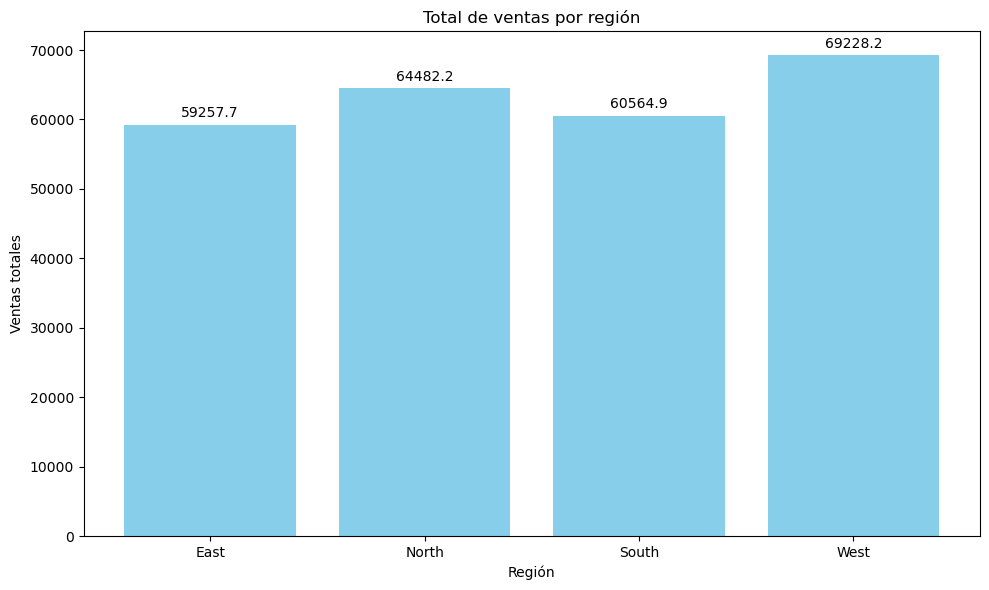

In [29]:
#Grafico
# Lienzo y tamaño
fig, ax = plt.subplots(figsize=(10, 6))
# Datos
barras = ax.bar(ventas_region.index, ventas_region.values, color='skyblue')

# 4. Agregar etiquetas a las barras
ax.bar_label(barras, padding=3) # padding es el espacio entre la barra y el número

plt.title('Total de ventas por región') # Titulo del gráfico
plt.xlabel('Región') # Titulo del eje x
plt.ylabel('Ventas totales') # Titulo del eje y
plt.xticks(rotation=360) 
plt.tight_layout()

plt.show()

En el gráfico anterior se muestra que la región con mayor número de ventas es la Oeste con 69 228.2, seguido del Norte, como se puede apreciar la mayoria se encuentra en un rango de 59 000 hasta 70 000. 


Ventas por mes

In [45]:
# Ventas por fecha
# 2. Ordenar por fecha
datos = datos.sort_values('Sale_Date')
# 3. Agrupar por fecha y sumar ventas
ventas_mensuales = datos.groupby(datos['Sale_Date'].dt.to_period('M')) ['Sale_Amount'].sum()

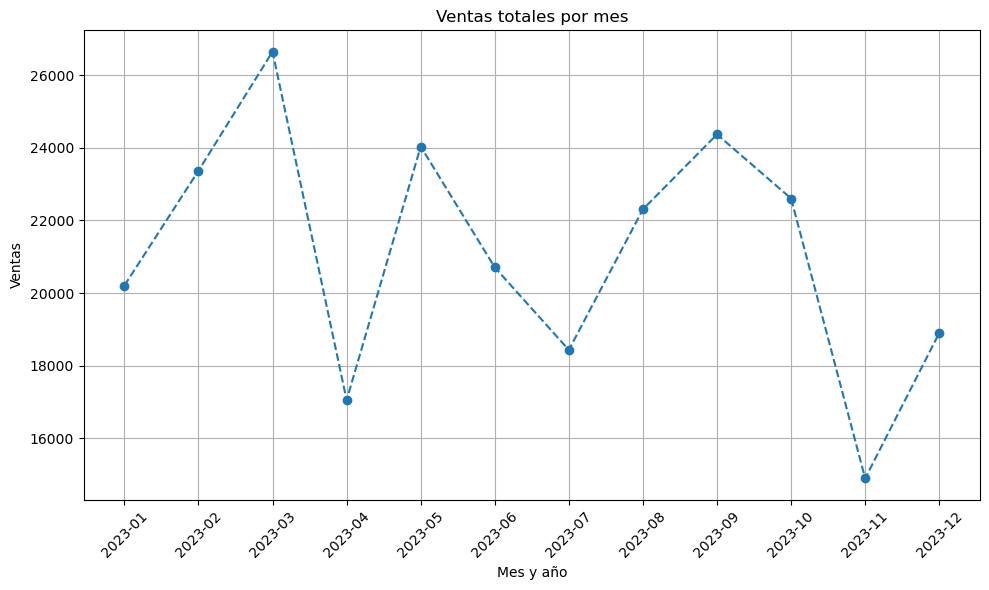

In [48]:
#Gráfico
# Definir el lienzo
fig, ax = plt.subplots(figsize=(10, 6))

# Dibujar la línea
ax.plot(ventas_mensuales.index.astype(str), ventas_mensuales.values, marker='o', linestyle='--')

# Configurar títulos y etiquetas
plt.title('Ventas totales por mes')
plt.xlabel('Mes y año')
plt.ylabel('Ventas') 
plt.grid(True)

# Rotar las fechas del eje X para que no se amontonen
plt.xticks(rotation=45)

# Ajustar márgenes para que no se corte nada
plt.tight_layout()

plt.show()

En el gráfico anterior se muestran las ventas totales por mes, el cual se aprecia que el mes de marzo en el año 2023 fue uno de los meses con mayor ventas, seguido de septiembre, sin embargo tuvo un decremento en los meses de abril y noviembre del mismo año. 

Ventas de región por mes

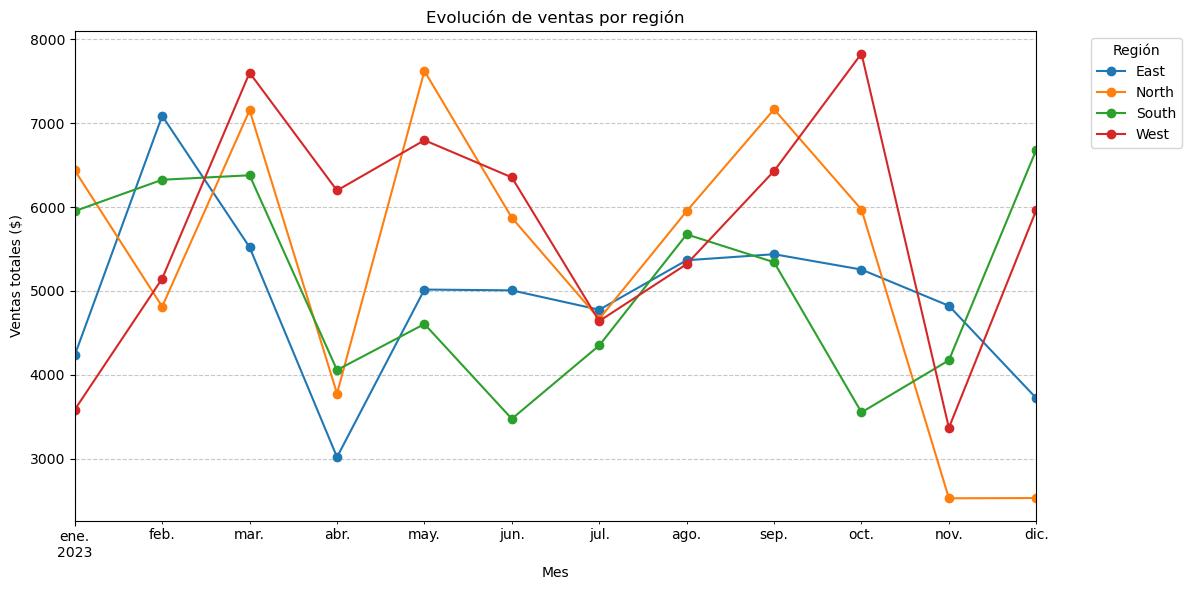

In [ ]:
# 1. Agrupar por mes y región
ventas_mes_region = datos.groupby([datos['Sale_Date'].dt.to_period('M'), 'Geography'])['Sale_Amount'].sum().unstack()

# 2. Graficar
fig, ax = plt.subplots(figsize=(12, 6))
# Línea por cada columna (región)
ventas_mes_region.plot(kind='line', marker='o', ax=ax)

# 
ax.set_title('Evolución de ventas por región')
ax.set_ylabel('Ventas totales')
ax.set_xlabel('Mes')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(title='Región', bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.show()

En el gráfico de evolución de ventas por región en el año 2023 se visualiza que la región del Oeste (rojo) y Norte (naranja) son de las regiones que destacaron, sin embargo, la región Norte presentó una alta volatilidad, registrando periodos de ventas significativas seguidos de un descenso drástico en noviembre, periodo tras el cual mantuvo un bajo desempeño hasta finalizar el año. 
De la misma manera, la región East (azul) parece ser la más estable; aunque no tiene los picos más altos, mantiene un comportamiento más predecible en comparación con las otras. 
Asimismo, el mes de julio parece ser un punto de convergencia donde casi todas las regiones tienen un rendimiento similar (cerca de los 4,500 - 5,000 ), lo cual podría ser un mes bajo general para toda la organización.

Clientes

In [6]:
import pandas as pd

# Base de datos
datos_clientes = pd.read_csv('customer_data_2023.csv')

# Para visualizar las primeras 5 filas 
datos_clientes.head()

,Customer_ID,Customer_Name,Customer_Age,Geography
0,1,Customer_1,20,West
1,2,Customer_2,69,North
2,3,Customer_3,57,West
3,4,Customer_4,66,East
4,5,Customer_5,59,South


In [7]:
# Tipo de datos de la base de datos junto con nulos
datos_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Customer_ID    300 non-null    int64 
 1   Customer_Name  300 non-null    object
 2   Customer_Age   300 non-null    int64 
 3   Geography      300 non-null    object
dtypes: int64(2), object(2)
memory usage: 9.5+ KB


Los tipos de datos que esta manejando el data son para la variable de id_cliente es integer, seguido del nombre que es objeto o texto, la edad es integer y la región es objeto.

In [8]:
# Datos nulos
datos_clientes.isnull().sum()

Customer_ID      0
Customer_Name    0
Customer_Age     0
Geography        0
dtype: int64

De acuerdo con la tabla anterior, se visualiza que no hay nulos en la base de datos.

In [9]:
#Cambio de tipo de dato
#Geographic cambia a categoria solo porque contiene pocas opciones
datos_clientes['Geography']=datos_clientes['Geography'].astype('category')

In [10]:
#Revisar si los campos se convirtieron en el tipo de campo deseado
print(datos_clientes.dtypes)

Customer_ID         int64
Customer_Name      object
Customer_Age        int64
Geography        category
dtype: object


In [11]:
# Cuenta cuántas filas están repetidas completamente
datos_clientes.duplicated().sum()

np.int64(0)

No hay datos repetidos en la data

Resultados

Clientes por región

In [12]:
#Clientes agrupados por región
import pandas as pd
import matplotlib.pyplot as plt

clientes_region = datos_clientes.groupby('Geography',observed=False)['Customer_Name'].count()

# Mostrar la tabla resultante
print(clientes_region)

Geography
East     82
North    73
South    73
West     72
Name: Customer_Name, dtype: int64


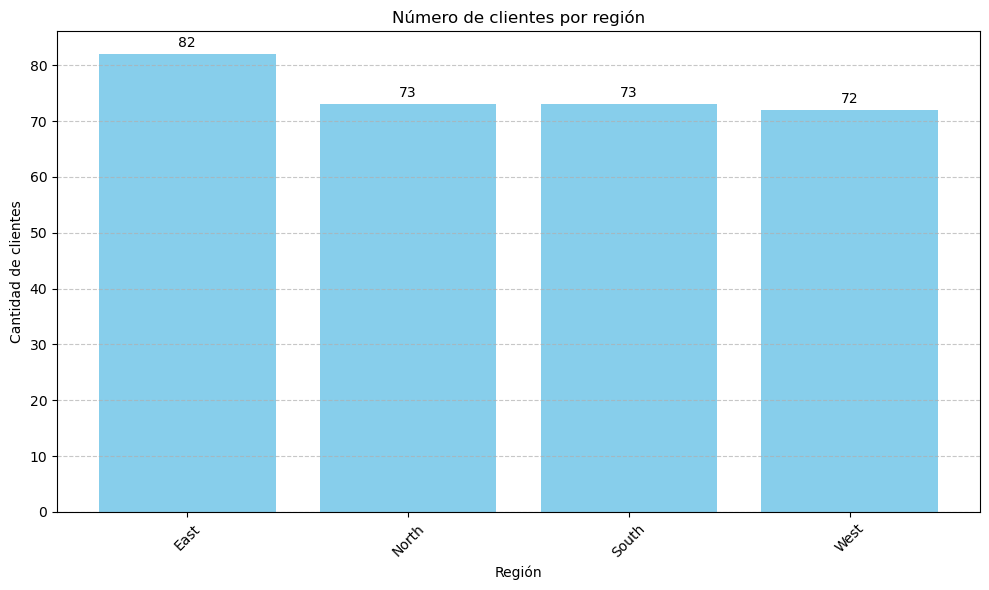

In [ ]:
# Gráfico de barras
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6)) # lienzo
barras = ax.bar(clientes_region.index, clientes_region.values, color='skyblue')

# 4. Agregar etiquetas a las barras
ax.bar_label(barras, padding=3) # padding es el espacio entre la barra y el número
plt.title('Número de clientes por región')
plt.xlabel('Región')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

La región con mayor número de clientes es el este, seguido de norte, en este cabe mencionar que coincide con las ventas totales donde tambien la región norte toma el segundo lugar.

Edad de los clientes

In [17]:
#Edad de los clientes
import pandas as pd
import matplotlib.pyplot as plt

clientes_edad = datos_clientes.groupby('Customer_Age',observed=False)['Customer_ID'].count()

# Mostrar la tabla resultante
print(clientes_edad)

Customer_Age
18     7
19     6
20     2
21    11
22     4
23     7
24     5
25     2
26     5
27     5
28     7
29    11
30     8
31     9
32     4
33     6
34     7
35     6
36     9
37     5
38     4
39     5
40     4
41     9
42     9
43     7
44     9
45     5
46    10
47     5
48     1
49     3
50     7
51     5
52     6
53     2
54     9
55     1
56     4
57     6
58     7
59     8
60     6
61     3
62     7
63     5
64     4
65     5
66    11
67     2
68     1
69     4
Name: Customer_ID, dtype: int64


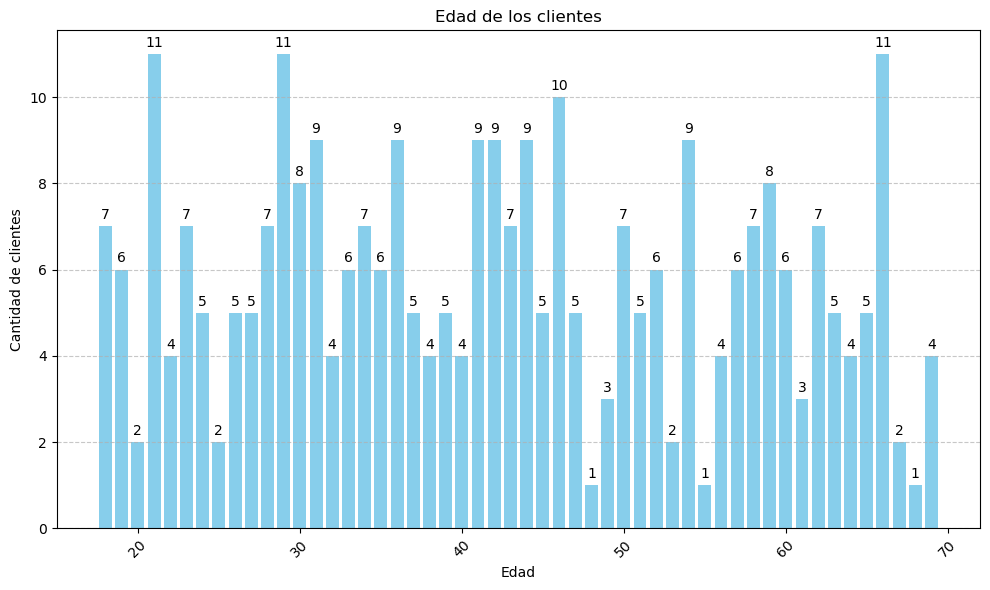

In [20]:
# Gráfico de barras
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6)) # lienzo
barras = ax.bar(clientes_edad.index, clientes_edad.values, color='skyblue')

# 4. Agregar etiquetas a las barras
ax.bar_label(barras, padding=3) # padding es el espacio entre la barra y el número
plt.title('Edad de los clientes')
plt.xlabel('Edad')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

En el gráfico de la edad de los clientes se visualiza que las edad con mayor frecuencia son 21, 29 y 66 años, por el contrario, las edades con menor frecuencia son 48, 55 y 69. Asimismo, la mayoria de los clientes se encuentra en un rango de dad de 25 y 47. 